<a href="https://colab.research.google.com/github/2303A52420/Exp-AI/blob/main/EAI_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
from sklearn.inspection import partial_dependence

print("\nCalculating Partial Dependence values manually...")

# Manually calculate partial dependence for each feature
pdp_results = {}
for feature in features_to_plot:
    print(f"Calculating PDP for feature(s): {feature}")
    results = partial_dependence(estimator=pipeline,
                                 X=X_test, # Use the unprocessed data with the pipeline
                                 features=feature,
                                 feature_names=X.columns.tolist(), # Original feature names
                                 kind='average',
                                 grid_resolution=20) # Use the same grid resolution

    # Store the results. Check if 'values' key exists before accessing.
    pdp_entry = {'average': results['average']}
    if 'values' in results:
        pdp_entry['values'] = results['values']

    pdp_results[str(feature)] = pdp_entry


print("\nPartial Dependence values calculated.")


Calculating Partial Dependence values manually...
Calculating PDP for feature(s): count_Like
Calculating PDP for feature(s): count_Purchase
Calculating PDP for feature(s): time_of_day
Calculating PDP for feature(s): ('count_Like', 'count_Purchase')

Partial Dependence values calculated.



Plotting Partial Dependence results manually...


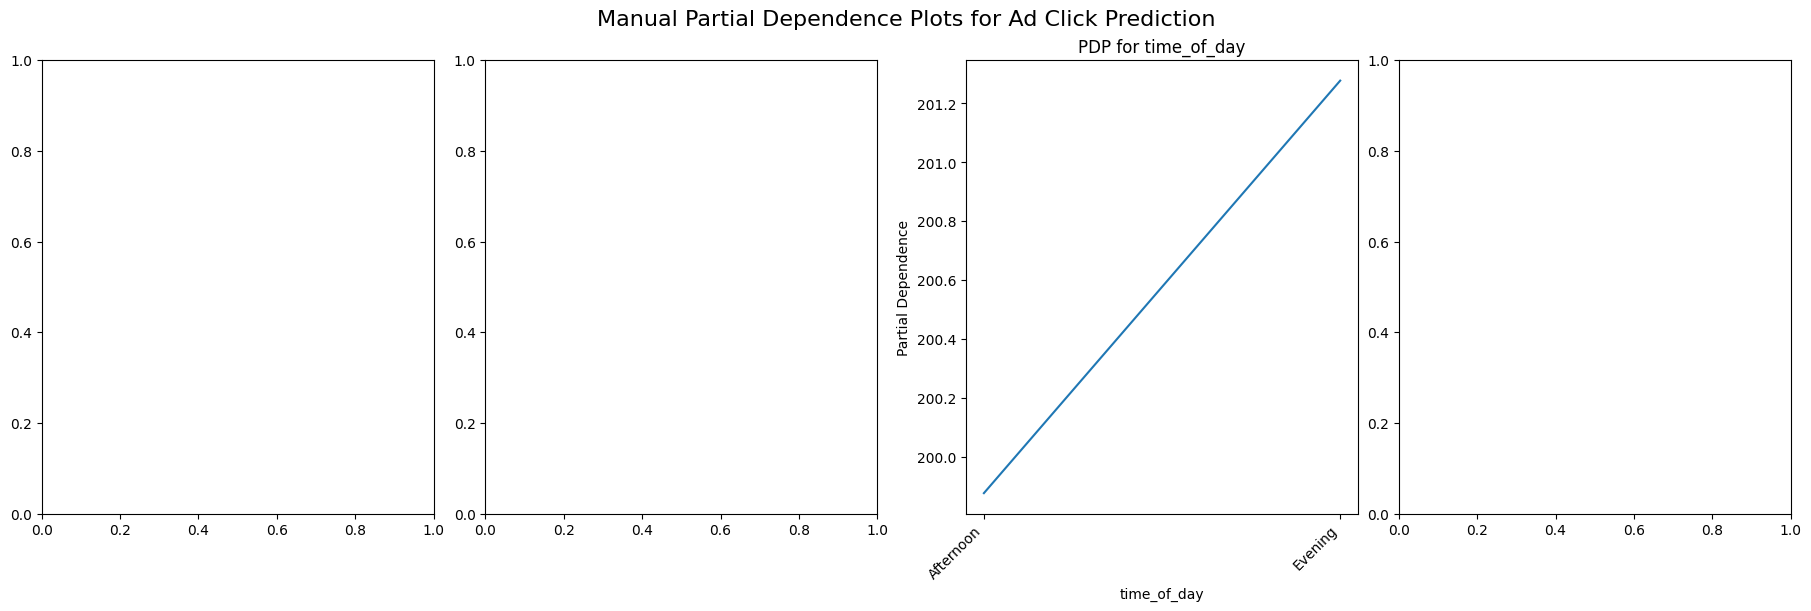


Manual PDPs generated successfully.


In [11]:
# Manually plot the Partial Dependence results
fig, axes = plt.subplots(figsize=(18, 6), ncols=len(features_to_plot), constrained_layout=True)

# Ensure axes is an iterable even if there's only one plot
if len(features_to_plot) == 1:
    axes = [axes]

print("\nPlotting Partial Dependence results manually...")

for i, feature in enumerate(features_to_plot):
    feature_str = str(feature)
    pdp_avg = pdp_results[feature_str]['average']

    if isinstance(feature, str): # 1D plot
        # For categorical features, values will be indices. Use original category names for ticks.
        if feature in categorical_features:
            # Get the categories from the original data (or the preprocessor if available)
            categories = preprocessor.named_transformers_['cat'].categories_[categorical_features.index(feature)]
            axes[i].plot(range(len(categories)), pdp_avg[0])
            axes[i].set_xticks(range(len(categories)))
            axes[i].set_xticklabels(categories, rotation=45, ha='right') # Rotate for readability
            axes[i].set_xlabel(feature)
        else: # Numerical features - 'values' key should exist
            if 'values' in pdp_results[feature_str]:
                pdp_values = pdp_results[feature_str]['values']
                axes[i].plot(pdp_values[0], pdp_avg[0])
                axes[i].set_xlabel(feature)
            else:
                print(f"Warning: 'values' key not found for numerical feature {feature}. Cannot plot.")
                continue # Skip plotting this feature if values are missing
        axes[i].set_ylabel("Partial Dependence")
        axes[i].set_title(f"PDP for {feature}")

    elif isinstance(feature, tuple) and len(feature) == 2: # 2D plot
        x_feature, y_feature = feature
        if 'values' in pdp_results[feature_str]:
            pdp_values_x = pdp_results[feature_str]['values'][0]
            pdp_values_y = pdp_results[feature_str]['values'][1]
            X_mesh, Y_mesh = np.meshgrid(pdp_values_x, pdp_values_y)
            Z = pdp_avg[0].reshape(X_mesh.shape) # Reshape average values for contour plot

            # Create a contour plot
            cs = axes[i].contourf(X_mesh, Y_mesh, Z, cmap='viridis', levels=20)
            fig.colorbar(cs, ax=axes[i], label='Partial Dependence')
            axes[i].set_xlabel(x_feature)
            axes[i].set_ylabel(y_feature)
            axes[i].set_title(f"Interaction PDP for {x_feature} and {y_feature}")
        else:
            print(f"Warning: 'values' key not found for interaction features {feature}. Cannot plot.")
            continue # Skip plotting this interaction if values are missing


fig.suptitle("Manual Partial Dependence Plots for Ad Click Prediction", fontsize=16)
plt.show()

print("\nManual PDPs generated successfully.")

In [16]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
# Import the LIME tabular explainer
import lime
import lime.lime_tabular

# --- 1. Data Loading and Aggregation (Reusing logic from pdp_analysis.py) ---
try:
    df_events = pd.read_csv("/content/ad_events.csv")
except FileNotFoundError:
    print("Error: ad_events.csv not found. Please ensure the file is correctly uploaded.")
    exit()

# 1.1 Calculate total events per ad_id
ad_performance = df_events.groupby('ad_id')['event_type'].value_counts().unstack(fill_value=0)
ad_performance.columns = [f'count_{col}' for col in ad_performance.columns]
ad_performance = ad_performance.reset_index()

# 1.2 Define Target and extract Time-based Features
target_column = 'count_Click'
if target_column not in ad_performance.columns:
    print(f"Warning: '{target_column}' not found. Check event_type values.")
    exit()

first_event_features = df_events.sort_values('timestamp').drop_duplicates('ad_id', keep='first')[['ad_id', 'day_of_week', 'time_of_day']]
ad_df = pd.merge(ad_performance, first_event_features, on='ad_id', how='left')

X = ad_df.drop(['ad_id', target_column, 'count_Impression'], axis=1, errors='ignore')
y = ad_df[target_column]

# --- 2. Preprocessing and Model Pipeline (Reusing logic) ---
categorical_features = ['day_of_week', 'time_of_day']
numerical_features = [col for col in X.columns if col not in categorical_features]

# The ColumnTransformer must be defined to output a DataFrame or a dense NumPy array
preprocessor = ColumnTransformer(
    transformers=[
        # OneHotEncode the categorical features
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)

xgb_regressor = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', xgb_regressor)
])

# Split data and train the model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)
print("Model training complete.")

# --- 3. LIME Implementation ---

# 3.1 Create a prediction function compatible with LIME
# LIME requires a function that takes a NumPy array of data (in the same format as training_data)
# and returns predictions.

def pipeline_predict(processed_data):
    """
    Takes a 2D numpy array of PROCESSED data (from LIME) and passes it through the pipeline.
    """
    # LIME samples in the processed feature space. The pipeline expects original features.
    # We need to create a DataFrame with original feature names from the processed data.

    # Get the original feature names
    original_feature_names = X.columns.tolist()

    # Create a DataFrame with original feature names.
    # This mapping from processed data columns back to original features is tricky
    # because of the one-hot encoding. LIME's data array has columns corresponding
    # to final_feature_names. We need to reverse the preprocessing.

    # A simpler approach is to pass the original data to the predict_fn
    # and let the pipeline handle the preprocessing internally.
    # However, LIME's explainer works on the processed data space.

    # Let's try reconstructing the original DataFrame structure
    # based on the knowledge of the preprocessor's output order.
    # This requires careful mapping back from the processed columns to the original.

    # Get the original categorical features and their categories
    cat_transformer = pipeline.named_steps['preprocessor'].named_transformers_['cat']
    ohe_categories = cat_transformer.categories_

    # Create a dictionary to map processed feature names to original feature names and their values
    processed_to_original = {}
    current_col = 0
    for i, cat_feature in enumerate(categorical_features):
        for category in ohe_categories[i]:
            # Map OHE column name back to original categorical feature name and its value
            ohe_col_name = f'{cat_feature}_{category}'
            processed_to_original[ohe_col_name] = {'original_feature': cat_feature, 'value': category, 'type': 'categorical'}
            current_col += 1

    for num_feature in numerical_features:
        processed_to_original[num_feature] = {'original_feature': num_feature, 'type': 'numerical'}
        current_col += 1

    # Create a DataFrame with original feature names
    original_df_reconstructed = pd.DataFrame(index=range(processed_data.shape[0]), columns=original_feature_names)

    # Fill the reconstructed DataFrame
    processed_feature_names = list(processed_to_original.keys())

    for i, processed_col_name in enumerate(processed_feature_names):
        mapping_info = processed_to_original[processed_col_name]
        original_feature = mapping_info['original_feature']

        if mapping_info['type'] == 'numerical':
            original_df_reconstructed[original_feature] = processed_data[:, i]
        elif mapping_info['type'] == 'categorical':
             # For categorical features, we need to find which original category
             # corresponds to the one-hot encoded value (which will be close to 0 or 1)
             # This is complex because LIME perturbs the data.

             # A more robust approach for LIME with a pipeline is to handle the preprocessing
             # *outside* the predict_fn and pass the original data to predict_fn,
             # but LIME requires the predict_fn to work on the same data format as training_data.

             # Let's reconsider the predict_fn. LIME expects a function that takes a numpy array
             # of the same format as training_data (which is processed). The pipeline.predict
             # expects a DataFrame with original column names.

             # The error is that df_temp created with final_feature_names is passed to pipeline.predict.
             # We need to pass a DataFrame with original column names to pipeline.predict.

             # Let's create a DataFrame with original column names and fill it.
             # The order of columns in processed_data corresponds to final_feature_names.
             # We need to map these back to original_feature_names.

             # This mapping is complex and error-prone. Let's simplify the predict_fn.
             # If we pass processed data to predict_fn, the pipeline should ideally
             # be able to handle processed data directly for the regressor step.
             # However, the preprocessor step is still part of the pipeline.

             # Let's try creating the DataFrame with original column names but
             # populate it by reversing the one-hot encoding for categorical features.
             # This requires knowing which processed columns map to which original categorical feature.

             # Let's go back to the initial idea: LIME provides processed data.
             # We need to somehow feed this into the pipeline which expects original data.
             # This implies reversing the preprocessing within pipeline_predict.

             # Reverse One-Hot Encoding:
             # Iterate through the one-hot encoded columns in processed_data.
             # For each row, find the column with the highest value (closest to 1)
             # within each original categorical feature group.
             # Assign the corresponding original category name to the original feature column.

            pass # This reverse mapping is complex and prone to errors with LIME's perturbations.


    # Let's rethink the pipeline_predict function based on the error.
    # The error happens because pipeline.predict receives a DataFrame with columns
    # that the preprocessor inside the pipeline doesn't expect (final_feature_names).
    # The preprocessor expects a DataFrame with original column names (X.columns).

    # We need to create a DataFrame with X.columns and fill it based on the
    # processed_data array and final_feature_names.

    df_original_format = pd.DataFrame(index=range(processed_data.shape[0]), columns=X.columns)

    # Fill numerical features directly (they are at the end of final_feature_names)
    num_features_start_index = len(ohe_feature_names)
    for i, num_feature in enumerate(numerical_features):
        df_original_format[num_feature] = processed_data[:, num_features_start_index + i]

    # Reverse One-Hot Encoding for categorical features
    current_processed_col = 0
    for i, cat_feature in enumerate(categorical_features):
        categories = ohe_categories[i]
        # Find the columns in processed_data corresponding to the OHE for this feature
        ohe_cols_indices = range(current_processed_col, current_processed_col + len(categories))

        # For each row in processed_data, find the index of the max value
        # within the current categorical feature's OHE columns.
        max_value_indices = np.argmax(processed_data[:, ohe_cols_indices], axis=1)

        # Map the index back to the original category name
        df_original_format[cat_feature] = [categories[idx] for idx in max_value_indices]

        current_processed_col += len(categories)

    # Now pass the DataFrame with original column names to the pipeline
    return pipeline.predict(df_original_format).reshape(-1, 1)


# 3.2 Select an instance to explain (e.g., the 5th ad in the test set)
instance_to_explain_index = 5
instance_raw = X_test.iloc[instance_to_explain_index] # Get the raw data instance
instance_label = y_test.iloc[instance_to_explain_index]

print(f"\nExplaining Ad ID at index {instance_to_explain_index} in X_test.")
print(f"Actual Clicks for this Ad: {instance_label}")
predicted_clicks = pipeline.predict(instance_raw.to_frame().T)[0] # Predict using the raw instance
print(f"Predicted Clicks for this Ad: {predicted_clicks:.2f}")

# 3.3 Initialize the LIME Explainer
# We need to pass the PROCESSED training data to the explainer
X_train_processed = pipeline['preprocessor'].transform(X_train)

# Get feature names of the processed data
ohe_feature_names = list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))
final_feature_names = ohe_feature_names + numerical_features

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_processed,                  # PROCESSED training data as a NumPy array
    feature_names=final_feature_names,                # Feature names of the PROCESSED data
    class_names=[target_column],                      # Target variable name
    # Categorical features in the processed data are the OHE columns.
    # We need to identify their indices.
    categorical_features=[i for i, name in enumerate(final_feature_names) if name in ohe_feature_names],
    # Categorical names are not directly used by LimeTabularExplainer in this mode,
    # as it works with the numerical OHE representation.
    # categorical_names={i: list(X[col].unique()) for i, col in enumerate(categorical_features)},
    kernel_width=0.75,
    verbose=False,
    mode='regression'                                 # Specify regression mode
)

# 3.4 Generate the explanation
# The LIME explainer samples around the instance and uses the pipeline_predict function.
# We need to pass the PROCESSED instance data to the explainer
instance_processed = pipeline['preprocessor'].transform(instance_raw.to_frame().T)[0]


explanation = explainer.explain_instance(
    data_row=instance_processed,            # The specific PROCESSED data point to explain
    predict_fn=pipeline_predict,            # The prediction function
    num_features=5                          # Number of features to include in the explanation
)

# --- 4. Visualization ---
print("\n--- LIME Explanation (Top 5 features) ---")
# Show the explanation as text in the console
print(explanation.as_list())

# Show the explanation graphically
fig = plt.figure(figsize=(10, 8))
explanation.show_in_notebook(show_table=True)
plt.show()

# You can also save the explanation HTML locally for better interactivity:
# explanation.save_to_file('lime_ad_explanation.html', show_table=True)
print("\nLIME explanation plot generated.")
print("The plot shows which features (and their values) locally contribute positively (green) or negatively (red) to the predicted number of Clicks for the selected ad.")

Model training complete.

Explaining Ad ID at index 5 in X_test.
Actual Clicks for this Ad: 195
Predicted Clicks for this Ad: 210.43

--- LIME Explanation (Top 5 features) ---
[('count_Purchase <= 8.00', 6.272021741362102), ('count_Like <= 55.00', 3.7265706101839213), ('count_Comment <= 18.00', 2.6547450551539966), ('count_Share > 11.00', -1.359655666814429), ('time_of_day_Afternoon=1', -0.5257540960298439)]


<Figure size 1000x800 with 0 Axes>


LIME explanation plot generated.
The plot shows which features (and their values) locally contribute positively (green) or negatively (red) to the predicted number of Clicks for the selected ad.


In [13]:
%pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=c62bfcfcfbc92021fece190391d24dab443e165cecfee3a8e8224e895e2d8458
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


Model training complete.

Generating ICE and PDP plots for features: count_Like, count_Share, count_Purchase


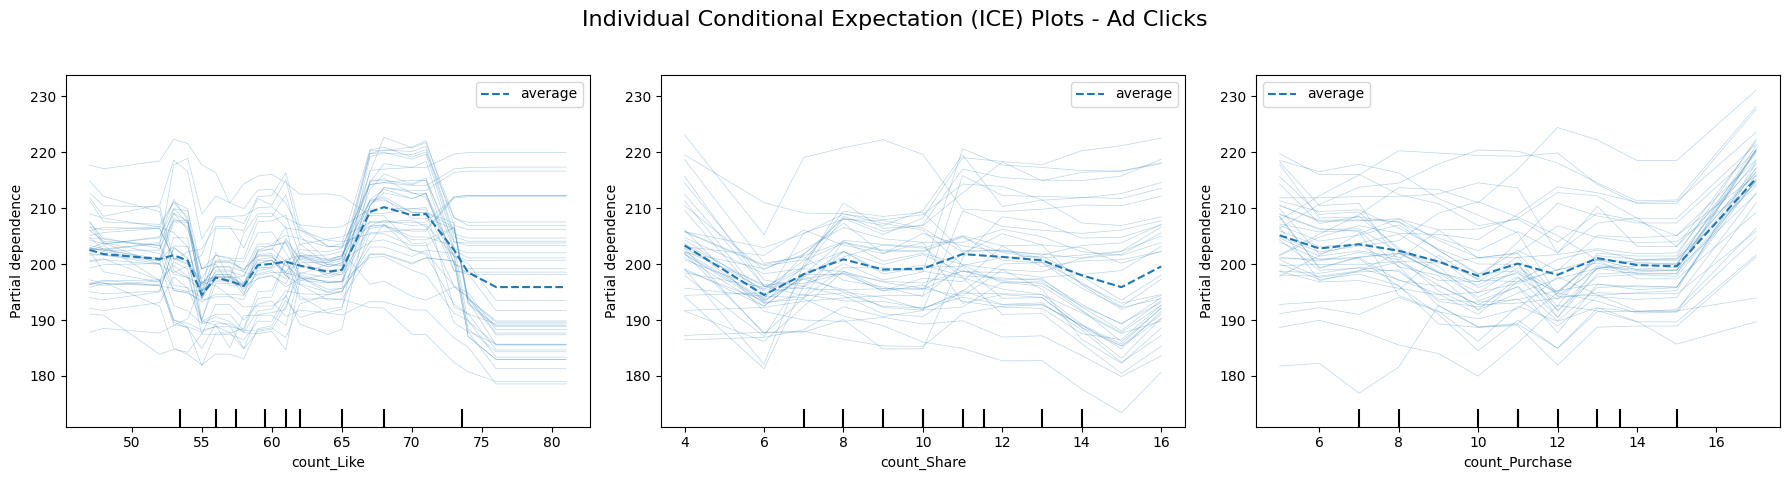


ICE plot generation complete.
Each thin line represents the predicted Clicks for a single ad as the feature on the x-axis changes.
Non-parallel lines indicate an interaction effect, meaning the impact of the feature depends on other features.


In [21]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.inspection import PartialDependenceDisplay # This generates both PDP and ICE

# --- 1. Data Loading and Aggregation (Reusing logic) ---
try:
    df_events = pd.read_csv("/content/ad_events.csv")
except FileNotFoundError:
    print("Error: ad_events.csv not found. Please ensure the file is correctly uploaded.")
    exit()

# 1.1 Calculate total events per ad_id
ad_performance = df_events.groupby('ad_id')['event_type'].value_counts().unstack(fill_value=0)
ad_performance.columns = [f'count_{col}' for col in ad_performance.columns]
ad_performance = ad_performance.reset_index()

# 1.2 Define Target and extract Time-based Features
target_column = 'count_Click'
if target_column not in ad_performance.columns:
    print(f"Warning: '{target_column}' not found. Check event_type values.")
    exit()

first_event_features = df_events.sort_values('timestamp').drop_duplicates('ad_id', keep='first')[['ad_id', 'day_of_week', 'time_of_day']]
ad_df = pd.merge(ad_performance, first_event_features, on='ad_id', how='left')

X = ad_df.drop(['ad_id', target_column, 'count_Impression'], axis=1, errors='ignore')
y = ad_df[target_column]

# --- 2. Preprocessing and Model Pipeline (Reusing logic) ---
categorical_features = ['day_of_week', 'time_of_day']
numerical_features = [col for col in X.columns if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)

xgb_regressor = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', xgb_regressor)
])

# Split data and train the model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)
print("Model training complete.")

# -----------------------------------------------------------------
# --- 3. Individual Conditional Expectation (ICE) Plot Generation ---
# -----------------------------------------------------------------

# Select key numerical features to analyze with ICE plots
features_for_ice = ['count_Like', 'count_Share', 'count_Purchase']

print(f"\nGenerating ICE and PDP plots for features: {', '.join(features_for_ice)}")

# Create subplots for each feature
fig, ax = plt.subplots(figsize=(18, 5), ncols=len(features_for_ice))

# Generate the display
display = PartialDependenceDisplay.from_estimator(
    estimator=pipeline,            # The trained pipeline
    X=X_test,                      # Data to compute dependence on
    features=features_for_ice,     # List of features to analyze
    feature_names=X.columns.tolist(),
    kind='both',                   # 'both' generates the ICE lines (individual) and the PDP line (average)
    subsample=50,                  # Plot only 50 random ICE lines for visual clarity
    n_jobs=-1,                     # Use all processors
    grid_resolution=50,            # High resolution for smoother curves
    ax=ax                          # Axes to plot on
)

fig.suptitle("Individual Conditional Expectation (ICE) Plots - Ad Clicks", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\nICE plot generation complete.")
print("Each thin line represents the predicted Clicks for a single ad as the feature on the x-axis changes.")
print("Non-parallel lines indicate an interaction effect, meaning the impact of the feature depends on other features.")


Data preprocessing complete.
Linear Regression model trained.

Model Performance (MSE): 157.12
Intercept: 209.45

--- Top 5 Positive Influence Coefficients (White Box Explanation) ---
These features INCREASE the predicted number of Clicks:
              Feature  Coefficient
  time_of_day_Evening     1.319854
        count_Comment     0.152729
day_of_week_Wednesday     0.000000
           count_Like    -0.055013
          count_Share    -0.258477

--- Top 5 Negative Influence Coefficients ---
These features DECREASE the predicted number of Clicks:
              Feature  Coefficient
day_of_week_Wednesday     0.000000
           count_Like    -0.055013
          count_Share    -0.258477
       count_Purchase    -0.496047
time_of_day_Afternoon    -1.319854


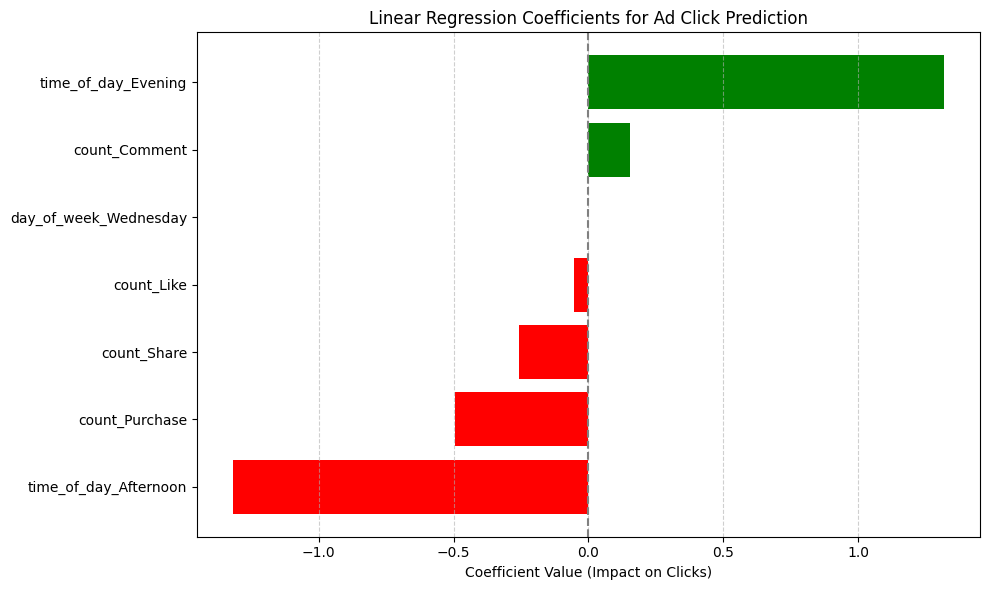


White box analysis complete. The plot and tables directly show the marginal impact of each feature on the predicted Clicks.


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# --- 1. Data Loading and Aggregation (Reusing logic) ---
try:
    df_events = pd.read_csv("/content/ad_events.csv")
except FileNotFoundError:
    print("Error: ad_events.csv not found. Please ensure the file is correctly uploaded.")
    exit()

# 1.1 Calculate total events per ad_id
ad_performance = df_events.groupby('ad_id')['event_type'].value_counts().unstack(fill_value=0)
ad_performance.columns = [f'count_{col}' for col in ad_performance.columns]
ad_performance = ad_performance.reset_index()

# 1.2 Define Target and extract Time-based Features
target_column = 'count_Click'
if target_column not in ad_performance.columns:
    print(f"Warning: '{target_column}' not found. Check event_type values.")
    exit()

first_event_features = df_events.sort_values('timestamp').drop_duplicates('ad_id', keep='first')[['ad_id', 'day_of_week', 'time_of_day']]
ad_df = pd.merge(ad_performance, first_event_features, on='ad_id', how='left')

X = ad_df.drop(['ad_id', target_column, 'count_Impression'], axis=1, errors='ignore')
y = ad_df[target_column]

# --- 2. Preprocessing and Model Training Setup ---
categorical_features = ['day_of_week', 'time_of_day']
numerical_features = [col for col in X.columns if col not in categorical_features]

# Preprocessor that handles categorical features and passes through numerical features
# We must use remainder='passthrough' and OneHotEncoder to ensure all numerical features are included.
preprocessor = ColumnTransformer(
    transformers=[
        # OneHotEncode the categorical features (creates many binary columns)
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the preprocessor on the training data and transform both train and test sets
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print("Data preprocessing complete.")

# 3.1 Get the full list of final feature names
# Get names of OHE features
ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
# Get names of numerical features (remainder='passthrough' keeps the original names)
numerical_feature_names = X_train.drop(categorical_features, axis=1).columns.tolist()

# Combine all feature names in the order they appear in the processed array
all_feature_names = list(ohe_feature_names) + numerical_feature_names

# --- 3. Linear Regression Model (The White Box Model) ---
lr_model = LinearRegression()
lr_model.fit(X_train_processed, y_train)
print("Linear Regression model trained.")

# --- 4. Interpretation (Extracting Coefficients) ---
# The coefficients are the heart of the white box explanation.

coefficients_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', ascending=False)

# 4.1 Evaluate Model Performance (for context)
y_pred = lr_model.predict(X_test_processed)
mse = mean_squared_error(y_test, y_pred)
print(f"\nModel Performance (MSE): {mse:.2f}")
print(f"Intercept: {lr_model.intercept_:.2f}")

# 4.2 Display the Top and Bottom Coefficients
print("\n--- Top 5 Positive Influence Coefficients (White Box Explanation) ---")
print("These features INCREASE the predicted number of Clicks:")
print(coefficients_df.head(5).to_string(index=False))

print("\n--- Top 5 Negative Influence Coefficients ---")
print("These features DECREASE the predicted number of Clicks:")
print(coefficients_df.tail(5).to_string(index=False))

# --- 5. Visualization of Coefficients ---
top_10 = pd.concat([coefficients_df.head(5), coefficients_df.tail(5)])
top_10 = top_10.sort_values(by='Coefficient', ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(top_10['Feature'], top_10['Coefficient'],
                color=['red' if c < 0 else 'green' for c in top_10['Coefficient']])
plt.title('Linear Regression Coefficients for Ad Click Prediction')
plt.xlabel('Coefficient Value (Impact on Clicks)')
plt.axvline(0, color='grey', linestyle='--')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\nWhite box analysis complete. The plot and tables directly show the marginal impact of each feature on the predicted Clicks.")


Data split: Training size 160, Test size 40

Starting XGBoost model training...
XGBoost Model Training Complete.

--- Model Performance Metrics (Predicting Clicks) ---
Train MSE: 17.13
Test MSE:  194.51
Train R-squared: 0.9003
Test R-squared:  -0.3216


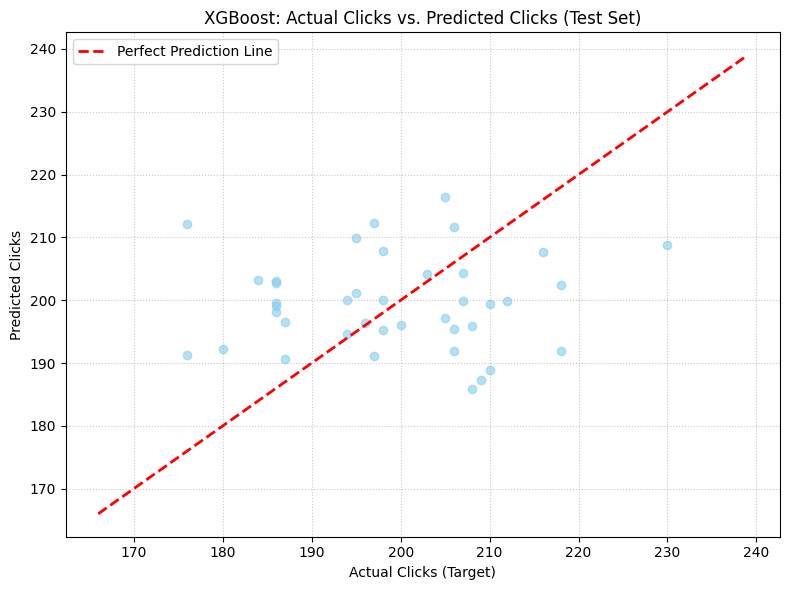


XGBoost analysis complete. The plot helps visualize the model's accuracy on the test data.


In [23]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# --- 1. Data Loading and Aggregation (Reusing standard logic) ---
try:
    df_events = pd.read_csv("/content/ad_events.csv")
except FileNotFoundError:
    print("Error: ad_events.csv not found. Please ensure the file is correctly uploaded.")
    exit()

# 1.1 Calculate total events per ad_id
ad_performance = df_events.groupby('ad_id')['event_type'].value_counts().unstack(fill_value=0)
ad_performance.columns = [f'count_{col}' for col in ad_performance.columns]
ad_performance = ad_performance.reset_index()

# 1.2 Define Target and extract Time-based Features
target_column = 'count_Click'
if target_column not in ad_performance.columns:
    print(f"Warning: '{target_column}' not found. Check event_type values.")
    exit()

# Get the initial event properties for the ad (used as proxy for ad placement/timing)
first_event_features = df_events.sort_values('timestamp').drop_duplicates('ad_id', keep='first')[['ad_id', 'day_of_week', 'time_of_day']]
ad_df = pd.merge(ad_performance, first_event_features, on='ad_id', how='left')

# Drop identifying and non-predictive columns
X = ad_df.drop(['ad_id', target_column, 'count_Impression'], axis=1, errors='ignore')
y = ad_df[target_column]

# --- 2. Preprocessing Setup ---
categorical_features = ['day_of_week', 'time_of_day']
numerical_features = [col for col in X.columns if col not in categorical_features]

# Preprocessor: Standardize numerical, One-Hot Encode categorical
preprocessor = ColumnTransformer(
    transformers=[
        # Numerical features: Standardize (not strictly necessary for XGBoost, but good practice)
        ('num', StandardScaler(), numerical_features),
        # Categorical features: One-Hot Encode
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Data split: Training size {X_train.shape[0]}, Test size {X_test.shape[0]}")

# --- 3. XGBoost Model Pipeline and Training ---
xgb_regressor = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=200,             # Increased estimators for potentially better fit
    learning_rate=0.05,           # Slower learning rate
    max_depth=5,                  # Deeper trees
    random_state=42,
    tree_method='hist'            # Fast training method
)

# Create the full modeling pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', xgb_regressor)
])

print("\nStarting XGBoost model training...")
pipeline.fit(X_train, y_train)
print("XGBoost Model Training Complete.")

# --- 4. Evaluation ---
y_pred_train = pipeline.predict(X_train)
y_pred_test = pipeline.predict(X_test)

# Calculate metrics
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# 4.1 Display Metrics
print("\n--- Model Performance Metrics (Predicting Clicks) ---")
print(f"Train MSE: {mse_train:.2f}")
print(f"Test MSE:  {mse_test:.2f}")
print(f"Train R-squared: {r2_train:.4f}")
print(f"Test R-squared:  {r2_test:.4f}")

# 4.2 Visualization: Actual vs. Predicted Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, alpha=0.6, color='skyblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction Line')
plt.title('XGBoost: Actual Clicks vs. Predicted Clicks (Test Set)')
plt.xlabel('Actual Clicks (Target)')
plt.ylabel('Predicted Clicks')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

print("\nXGBoost analysis complete. The plot helps visualize the model's accuracy on the test data.")
